In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import os
import sys
import datetime as dt

In [2]:
df = pl.read_csv("../data/raw_data_phase2_v0/Encounters with Level Start Times - 2.6.csv",
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])

In [28]:
ORDER_COLS=["UPOA-1", "UPOA-2", "UPOA-3", "NPOA-1", "NPOA-2", "NPOA-3", "POA-1", "POA-2", "POA-3"]

In [85]:
df['InpatientAdmissionInstant'].min(), df['InpatientAdmissionInstant'].max()

(datetime.datetime(2024, 1, 6, 20, 15), datetime.datetime(2025, 12, 31, 2, 42))

In [86]:
df['EncounterEpicCsn'].n_unique()

4727

In [3]:
len(df.schema)

41

In [4]:
df.head(), df.shape

(shape: (5, 41)
 ┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
 │ Encounter ┆ Sepsis_Ca ┆ Inpatient ┆ Suspected ┆ … ┆ Max_Vasop ┆ Max_Pheny ┆ Max_Norep ┆ Max_Epin │
 │ EpicCsn   ┆ tegory    ┆ Admission ┆ _Infectio ┆   ┆ ressin_Do ┆ lephrine_ ┆ inephrine ┆ ephrine_ │
 │ ---       ┆ ---       ┆ Instant   ┆ n_Datetim ┆   ┆ se        ┆ Dose      ┆ _Dose     ┆ Dose     │
 │ i64       ┆ str       ┆ ---       ┆ e         ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
 │           ┆           ┆ str       ┆ ---       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
 │           ┆           ┆           ┆ str       ┆   ┆           ┆           ┆           ┆          │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
 │ 741572231 ┆ NPOA-1    ┆ 12/2/25   ┆ 12/3/25   ┆ … ┆ null      ┆ null      ┆ null      ┆ null     │
 │           ┆           ┆ 10:23 AM  ┆ 11:21 PM  ┆   ┆           ┆

In [5]:
df['EncounterEpicCsn'].n_unique()

4727

In [90]:
df['Sepsis_Category'].value_counts(ord)

Sepsis_Category,count
str,u64
"""POA-1""",1720
"""UPOA-3""",81
"""NPOA-2""",42
"""POA-3""",854
"""NPOA-1""",215
"""UPOA-2""",75
"""UPOA-1""",639
"""NPOA-3""",306
"""POA-2""",795


<Axes: xlabel='Sepsis_Category', ylabel='count'>

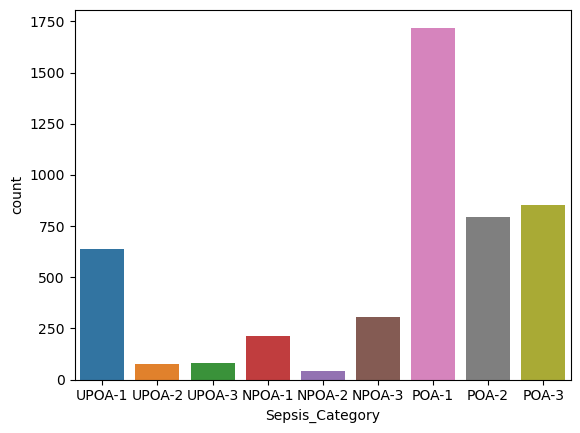

In [29]:
sns.barplot(
    df['Sepsis_Category'].value_counts().to_pandas(),
    x="Sepsis_Category",
    y="count",
    order=ORDER_COLS
)

In [6]:
datetime_cols = list(filter(lambda x: 'date' in x.lower() or 'instant' in x.lower(), df.columns))
dt_expr = [
    pl.col(c).str.strptime(pl.Datetime, format="%m/%d/%y %I:%M %p") for c in datetime_cols
]
df = df.with_columns(
    dt_expr
)

In [7]:
df = df.with_columns(
    admit_2_s1_hrs = (pl.col("Sepsis_1_Begin_DateTime")-pl.col("InpatientAdmissionInstant")).dt.total_hours(),
    admit_2_s2_hrs = (pl.col("Sepsis_2_Begin_DateTime")-pl.col("InpatientAdmissionInstant")).dt.total_hours(),
    admit_2_s3_hrs = (pl.col("Sepsis_3_Begin_DateTime")-pl.col("InpatientAdmissionInstant")).dt.total_hours(),
    admit_2_infect_hrs = (pl.col("Suspected_Infection_Datetime")-pl.col("InpatientAdmissionInstant")).dt.total_hours(),
    s2_2_s1_hrs = (pl.col("Sepsis_2_Begin_DateTime")-pl.col("Sepsis_1_Begin_DateTime")).dt.total_hours(),
    s3_2_s2_hrs = (pl.col("Sepsis_3_Begin_DateTime")-pl.col("Sepsis_2_Begin_DateTime")).dt.total_hours(),
    s3_2_s1_hrs = (pl.col("Sepsis_3_Begin_DateTime")-pl.col("Sepsis_1_Begin_DateTime")).dt.total_hours(),
    s1_2_infect_hrs = (pl.col("Sepsis_1_Begin_DateTime")-pl.col("Suspected_Infection_Datetime")).dt.total_hours(),
    s2_2_infect_hrs = (pl.col("Sepsis_2_Begin_DateTime")-pl.col("Suspected_Infection_Datetime")).dt.total_hours(),
    s3_2_infect_hrs = (pl.col("Sepsis_3_Begin_DateTime")-pl.col("Suspected_Infection_Datetime")).dt.total_hours()
)

In [8]:
df.select(["Sepsis_Category"]+[c for c in df.columns if c.endswith('_hrs')])

Sepsis_Category,admit_2_s1_hrs,admit_2_s2_hrs,admit_2_s3_hrs,admit_2_infect_hrs,s2_2_s1_hrs,s3_2_s2_hrs,s3_2_s1_hrs,s1_2_infect_hrs,s2_2_infect_hrs,s3_2_infect_hrs
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""NPOA-1""",40,141,null,36,101,null,null,3,104,null
"""NPOA-3""",35,35,35,35,0,0,0,0,0,0
"""POA-3""",-8,-4,0,-9,4,5,9,0,4,9
"""POA-1""",-38,null,null,-39,null,null,null,0,null,null
"""POA-1""",0,null,10,-6,null,null,10,6,null,16
…,…,…,…,…,…,…,…,…,…,…
"""POA-2""",4,6,null,3,2,null,null,0,2,null
"""UPOA-1""",null,null,null,null,null,null,null,null,null,null
"""POA-1""",-1,null,null,-2,null,null,null,1,null,null


<Axes: xlabel='Sepsis_Category', ylabel='s3_2_s2_hrs'>

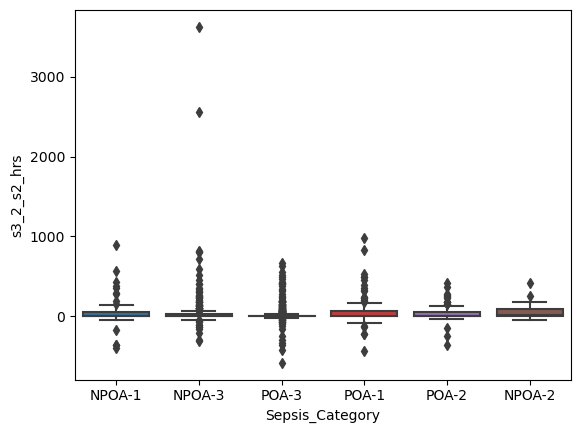

In [9]:
sns.boxplot(
    data=df.filter(pl.col("Sepsis_Category").str.contains("^POA|^NPOA")).to_pandas(),
    x='Sepsis_Category',
    y="s3_2_s2_hrs",

)

In [10]:
df.filter(pl.col("s3_2_s2_hrs")<0).shape,df.filter(pl.col("s3_2_s1_hrs")<0).shape, df.filter(pl.col("s2_2_s1_hrs")<0).shape

((114, 51), (0, 51), (0, 51))

In [11]:
df.filter((pl.col("s3_2_s2_hrs")<0)&(pl.col("Sepsis_Category").str.contains("^NPOA")))\
    .select("EncounterEpicCsn", "Sepsis_Category",
        'Sepsis_1_Begin_DateTime',
        'Sepsis_2_Begin_DateTime',
        'Sepsis_3_Begin_DateTime'
    )

EncounterEpicCsn,Sepsis_Category,Sepsis_1_Begin_DateTime,Sepsis_2_Begin_DateTime,Sepsis_3_Begin_DateTime
i64,str,datetime[μs],datetime[μs],datetime[μs]
720741720,"""NPOA-3""",2025-02-10 06:20:00,2025-02-15 06:33:00,2025-02-14 05:38:00
722735094,"""NPOA-3""",2025-03-22 02:41:00,2025-03-25 04:20:00,2025-03-22 11:45:00
722589613,"""NPOA-1""",2025-04-25 17:00:00,2025-04-26 20:29:00,2025-04-26 11:18:00
725428715,"""NPOA-3""",2025-04-22 18:00:00,2025-04-24 15:06:00,2025-04-23 00:24:00
719241770,"""NPOA-2""",2025-01-15 16:22:00,2025-01-27 05:15:00,2025-01-25 02:28:00
…,…,…,…,…
730634967,"""NPOA-3""",2025-09-23 09:44:00,2025-09-26 14:40:00,2025-09-26 02:00:00
718097945,"""NPOA-1""",2024-12-20 12:41:00,2024-12-29 07:39:00,2024-12-28 09:00:00
719121929,"""NPOA-1""",2025-01-08 20:59:00,2025-01-18 05:15:00,2025-01-16 06:30:00


# Q1:
What is the % of correctly categorized "Present on Admission" (defined by hours from admission to sepsis 1 < 48 = Present)?


Text(0.5, 1.0, 'Probabilities (den is # encs with sepsis 1 flag within 48 hrs of admit)')

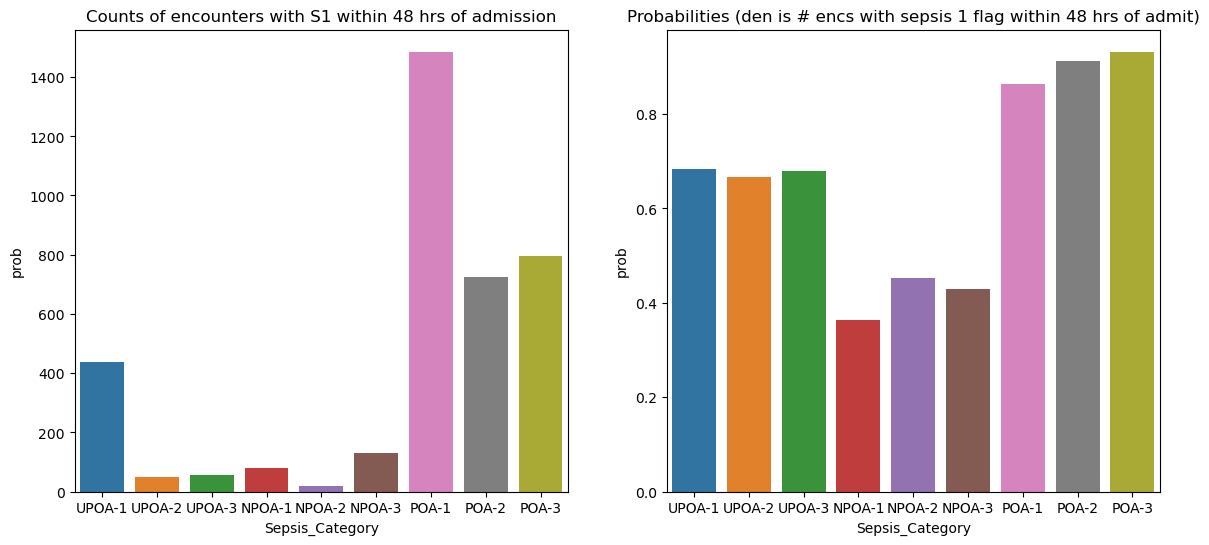

In [41]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

sns.barplot(
df['Sepsis_Category'].value_counts().join(
    df.filter(
        pl.col("admit_2_s1_hrs")<48
    )['Sepsis_Category'].value_counts(),
    on='Sepsis_Category',
    suffix="_filter"
).with_columns(
    prob=pl.col("count_filter")
).sort(by='Sepsis_Category').to_pandas(), x='Sepsis_Category', y='prob', order=ORDER_COLS, ax=axes[0])
axes[0].set_title("Counts of encounters with S1 within 48 hrs of admission")

sns.barplot(
df['Sepsis_Category'].value_counts().join(
    df.filter(
        pl.col("admit_2_s1_hrs")<48
    )['Sepsis_Category'].value_counts(),
    on='Sepsis_Category',
    suffix="_filter"
).with_columns(
    prob=pl.col("count_filter")/pl.col("count")
).sort(by='Sepsis_Category').to_pandas(), x='Sepsis_Category', y='prob', order=ORDER_COLS, ax=axes[1])
axes[1].set_title("Probabilities (den is # encs with sepsis 1 flag within 48 hrs of admit)")


/tmp/ipykernel_1302745/4154477535.py:9: DeprecationWarning:

the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.



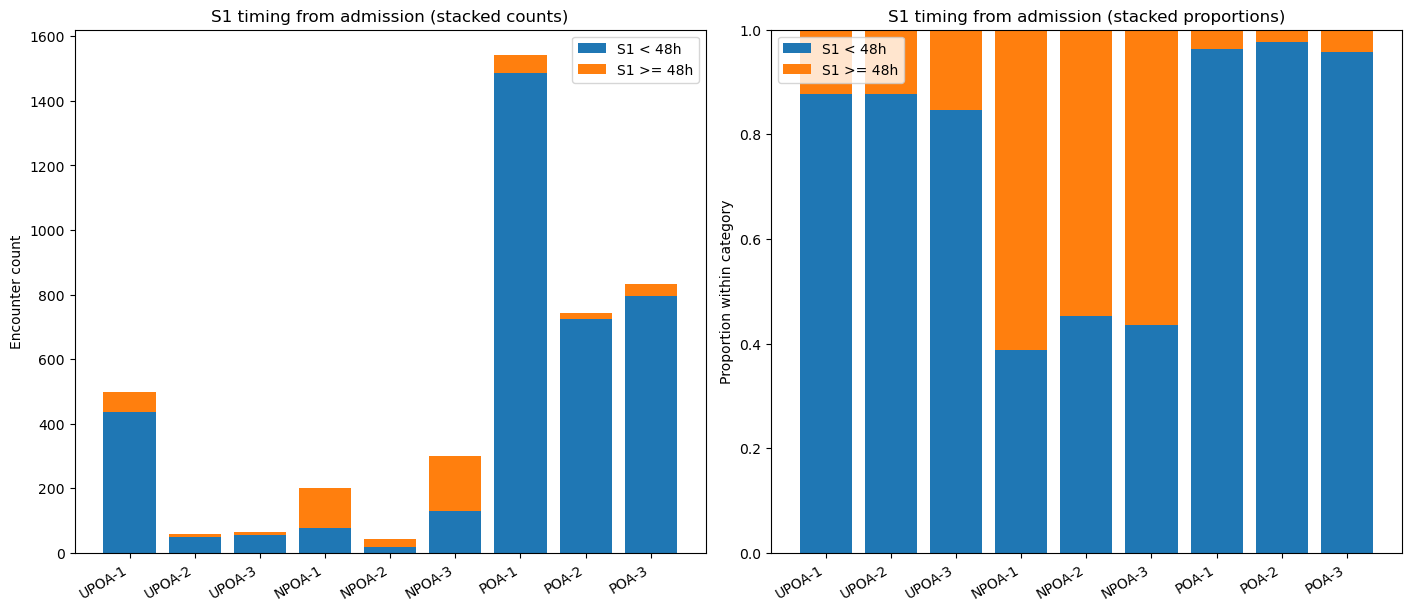

In [95]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

THRESH_HRS = 48

# ----- Build stacked counts per category -----
df_stack = (
    df
    .filter(pl.col("admit_2_s1_hrs").is_not_null())
    .with_columns(
        pl.when(pl.col("admit_2_s1_hrs") < THRESH_HRS)
          .then(pl.lit("lt_48h"))
          .otherwise(pl.lit("ge_48h"))
          .alias("bucket")
    )
    .group_by(["Sepsis_Category", "bucket"])
    .len()
    .rename({"len": "n"})
    .pivot(
        values="n",
        index="Sepsis_Category",
        columns="bucket",
        aggregate_function="first"
    )
    .with_columns([
        pl.col("lt_48h").fill_null(0),
        pl.col("ge_48h").fill_null(0),
    ])
    .with_columns([
        (pl.col("lt_48h") + pl.col("ge_48h")).alias("total"),
        (pl.when((pl.col("lt_48h") + pl.col("ge_48h")) > 0)
           .then(pl.col("lt_48h") / (pl.col("lt_48h") + pl.col("ge_48h")))
           .otherwise(0.0)
        ).alias("p_lt"),
        (pl.when((pl.col("lt_48h") + pl.col("ge_48h")) > 0)
           .then(pl.col("ge_48h") / (pl.col("lt_48h") + pl.col("ge_48h")))
           .otherwise(0.0)
        ).alias("p_ge"),
    ])
)

# ----- Force ORDER_COLS (and include missing cats as 0s) -----
df_order = pl.DataFrame({"Sepsis_Category": ORDER_COLS})

df_stack = (
    df_order.join(df_stack, on="Sepsis_Category", how="left")
    .with_columns([
        pl.col("lt_48h").fill_null(0),
        pl.col("ge_48h").fill_null(0),
        pl.col("total").fill_null(0),
        pl.col("p_lt").fill_null(0.0),
        pl.col("p_ge").fill_null(0.0),
    ])
)

pdf = df_stack.to_pandas()

cats = pdf["Sepsis_Category"].tolist()
x = np.arange(len(cats))

n_lt = pdf["lt_48h"].to_numpy()
n_ge = pdf["ge_48h"].to_numpy()

p_lt = pdf["p_lt"].to_numpy()
p_ge = pdf["p_ge"].to_numpy()

# ----- Plot -----
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# Stacked counts
axes[0].bar(x, n_lt, label="S1 < 48h")
axes[0].bar(x, n_ge, bottom=n_lt, label="S1 >= 48h")
axes[0].set_xticks(x)
axes[0].set_xticklabels(cats, rotation=30, ha="right")
axes[0].set_ylabel("Encounter count")
axes[0].set_title("S1 timing from admission (stacked counts)")

# Stacked proportions
axes[1].bar(x, p_lt, label="S1 < 48h")
axes[1].bar(x, p_ge, bottom=p_lt, label="S1 >= 48h")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats, rotation=30, ha="right")
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("Proportion within category")
axes[1].set_title("S1 timing from admission (stacked proportions)")

for ax in axes:
    ax.legend()

plt.show()


# Q2:
% of encounters with no "Suspected Infection" action?

In [13]:
print(f"Patients with no suspected infection time: {df['Suspected_Infection_Datetime'].is_null().sum()} ...")

Patients with no suspected infection time: 446 ...


Text(0.5, 1.0, '# of encounters with no suspected infection')

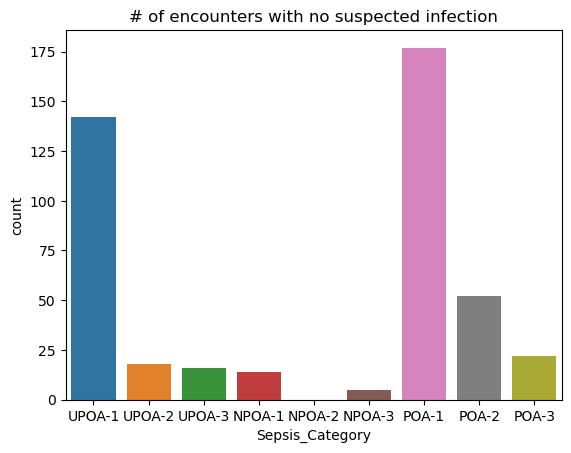

In [43]:
sns.barplot(
    df.filter(pl.col("Suspected_Infection_Datetime").is_null())['Sepsis_Category'].value_counts().sort(by='Sepsis_Category').to_pandas(),
    x = "Sepsis_Category",
    y='count',
    order = ["UPOA-1", "UPOA-2", "UPOA-3", "NPOA-1", "NPOA-2", "NPOA-3", "POA-1", "POA-2", "POA-3"]
)
plt.title("# of encounters with no suspected infection")

# Q3:
What is the average/median time from admission to infection suspicion?

In [15]:
admit_2_infect_vals = df['admit_2_infect_hrs'].drop_nulls().to_numpy()
per = []
for i in range(1, 100, 5):
    print(i)
    per.append(np.percentile(admit_2_infect_vals, i))
if i<99:
    per.append(np.percentile(admit_2_infect_vals, 99))
print(per)

1
6
11
16
21
26
31
36
41
46
51
56
61
66
71
76
81
86
91
96
[-44.0, -31.0, -22.0, -16.0, -10.0, -6.0, -5.0, -4.0, -3.0, -3.0, -2.0, -1.0, 0.0, 0.0, 1.0, 3.0, 6.0, 16.0, 51.80000000000018, 170.60000000000036, 386.3999999999987]


In [16]:
df['admit_2_infect_hrs'].mean(), df['admit_2_infect_hrs'].median()
# sns.displot(
#     df.to_pandas(),
#     x='admit_2_infect_hrs',
#     kind='hist',
#     hue='Sepsis_Category'
# )

px.histogram(
    df.to_pandas(),
    x='admit_2_infect_hrs',
    histfunc='count',
    
    
)

# Q4:
What percent have a Sepsis 1 time/Sepsis 2 time/Sepsis 3 time?

In [17]:
sepsis_1_nulls = df.filter(pl.col("Sepsis_1_Begin_DateTime").is_null())['EncounterEpicCsn'].unique().to_list()
sepsis_2_nulls = df.filter(pl.col("Sepsis_2_Begin_DateTime").is_null())['EncounterEpicCsn'].unique().to_list()
sepsis_3_nulls = df.filter(pl.col("Sepsis_3_Begin_DateTime").is_null())['EncounterEpicCsn'].unique().to_list()

In [18]:
len(sepsis_1_nulls), len(sepsis_2_nulls), len(sepsis_3_nulls)

(446, 2061, 3119)

In [19]:
df_sepsis_1 = df.filter(pl.col("Sepsis_1_Begin_DateTime").is_not_null())
df_sepsis_2 = df.filter(pl.col("Sepsis_2_Begin_DateTime").is_not_null())
df_sepsis_3 = df.filter(pl.col("Sepsis_3_Begin_DateTime").is_not_null())

df_pats_with_all_sepsis = df_sepsis_1.join(
    df_sepsis_2,
    on="EncounterEpicCsn",
    suffix="_2"
).join(
    df_sepsis_3,
    on="EncounterEpicCsn",
    suffix="_3"
)

In [20]:
# 
df_pats_with_all_sepsis['Sepsis_Category'].value_counts()

Sepsis_Category,count
str,u64
"""UPOA-1""",62
"""UPOA-3""",40
"""NPOA-3""",271
"""POA-2""",88
"""POA-3""",669
"""UPOA-2""",7
"""NPOA-2""",19
"""NPOA-1""",70
"""POA-1""",133


# Q5:
What is the average/median time from admission to Sepsis 1/Sepsis 2/Sepsis 3?

In [21]:
df.columns[-10:]

['admit_2_s1_hrs',
 'admit_2_s2_hrs',
 'admit_2_s3_hrs',
 'admit_2_infect_hrs',
 's2_2_s1_hrs',
 's3_2_s2_hrs',
 's3_2_s1_hrs',
 's1_2_infect_hrs',
 's2_2_infect_hrs',
 's3_2_infect_hrs']

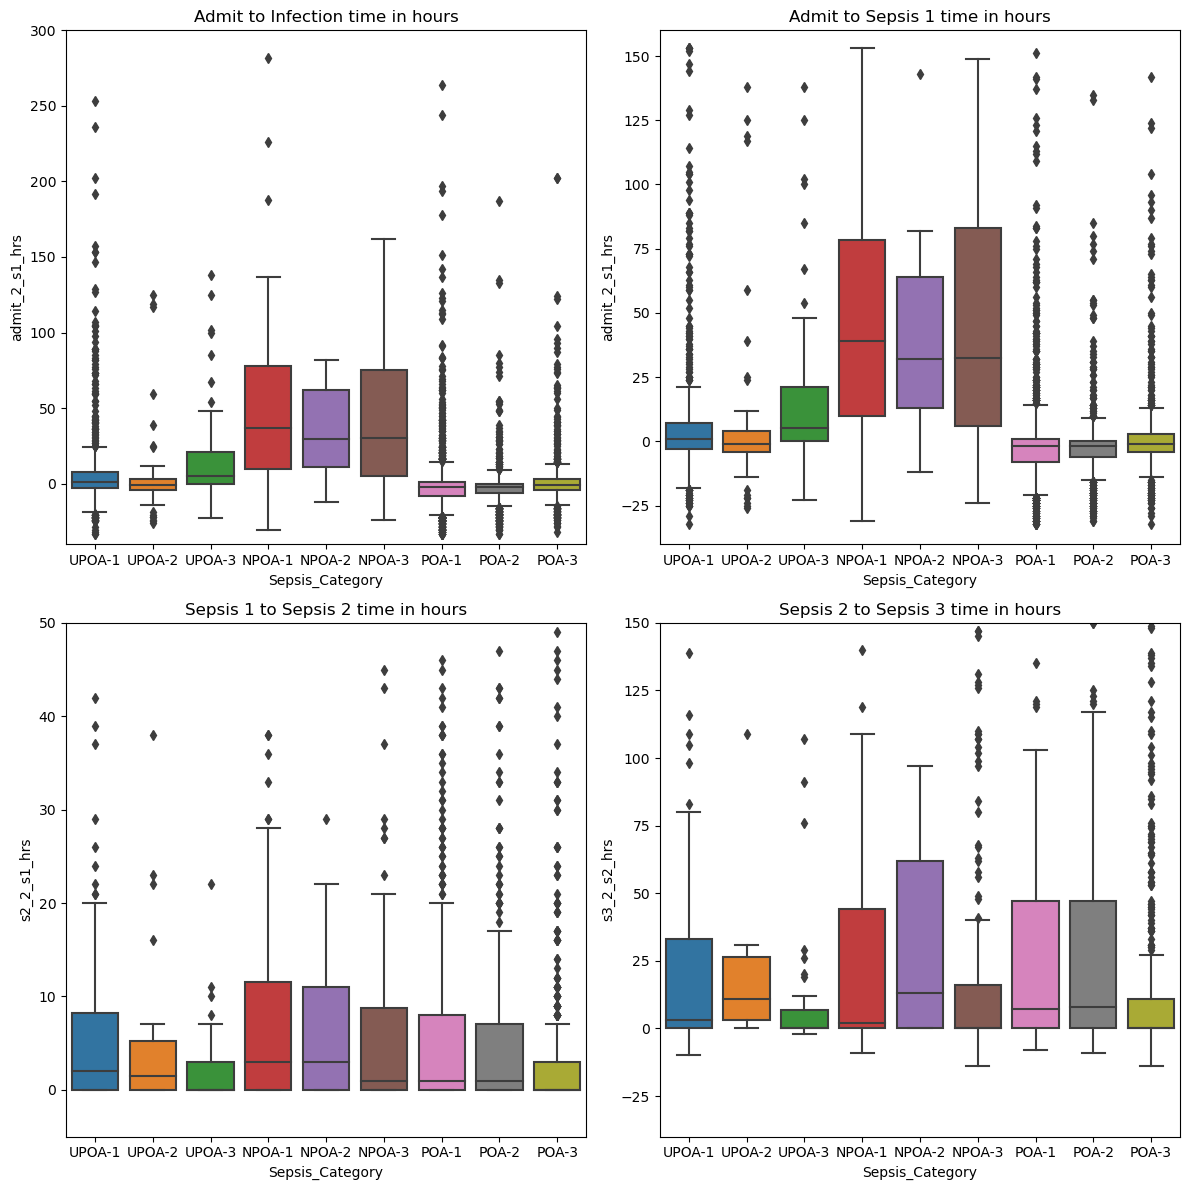

In [99]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

sns.boxplot(
    data=df.filter(
        (pl.col("admit_2_infect_hrs")>=pl.col("admit_2_infect_hrs").quantile(0.05))&
        (pl.col("admit_2_infect_hrs")<=pl.col("admit_2_infect_hrs").quantile(0.95))
        ).to_pandas(),
    x="Sepsis_Category",
    y="admit_2_s1_hrs",
    order=["UPOA-1","UPOA-2","UPOA-3","NPOA-1","NPOA-2","NPOA-3","POA-1","POA-2","POA-3"],
    ax=axes[0][0]
)
axes[0][0].set_title("Admit to Infection time in hours")
axes[0][0].set_ylim([-40, 300])

sns.boxplot(
    data=df.filter(
        (pl.col("admit_2_infect_hrs")>=pl.col("admit_2_s1_hrs").quantile(0.05))&
        (pl.col("admit_2_s1_hrs")<=pl.col("admit_2_s1_hrs").quantile(0.95))
        ).to_pandas(),
    x="Sepsis_Category",
    y="admit_2_s1_hrs",
    order=["UPOA-1","UPOA-2","UPOA-3","NPOA-1","NPOA-2","NPOA-3","POA-1","POA-2","POA-3"],
    ax=axes[0][1]
)
axes[0][1].set_title("Admit to Sepsis 1 time in hours")
axes[0][1].set_ylim([-40, 160])

sns.boxplot(
    data=df.filter(
        (pl.col("s2_2_s1_hrs")>=pl.col("s2_2_s1_hrs").quantile(0.05))&
        (pl.col("s2_2_s1_hrs")<=pl.col("s2_2_s1_hrs").quantile(0.95))
        ).to_pandas(),
    x="Sepsis_Category",
    y="s2_2_s1_hrs",
    order=["UPOA-1","UPOA-2","UPOA-3","NPOA-1","NPOA-2","NPOA-3","POA-1","POA-2","POA-3"],
    ax=axes[1][0]
)

axes[1][0].set_title("Sepsis 1 to Sepsis 2 time in hours")
axes[1][0].set_ylim([-5, 50])

sns.boxplot(
    data=df.filter(
        (pl.col("s3_2_s2_hrs")>=pl.col("s3_2_s2_hrs").quantile(0.05))&
        (pl.col("s3_2_s2_hrs")<=pl.col("s3_2_s2_hrs").quantile(0.95))
        ).to_pandas(),
    x="Sepsis_Category",
    y="s3_2_s2_hrs",
    order=["UPOA-1","UPOA-2","UPOA-3","NPOA-1","NPOA-2","NPOA-3","POA-1","POA-2","POA-3"],
    ax=axes[1][1]
)

axes[1][1].set_title("Sepsis 2 to Sepsis 3 time in hours")
axes[1][1].set_ylim([-40, 150])

plt.tight_layout()

# Q6:
What is the average/median time from Sepsis 1 to Sepsis 2/Sepsis 3?

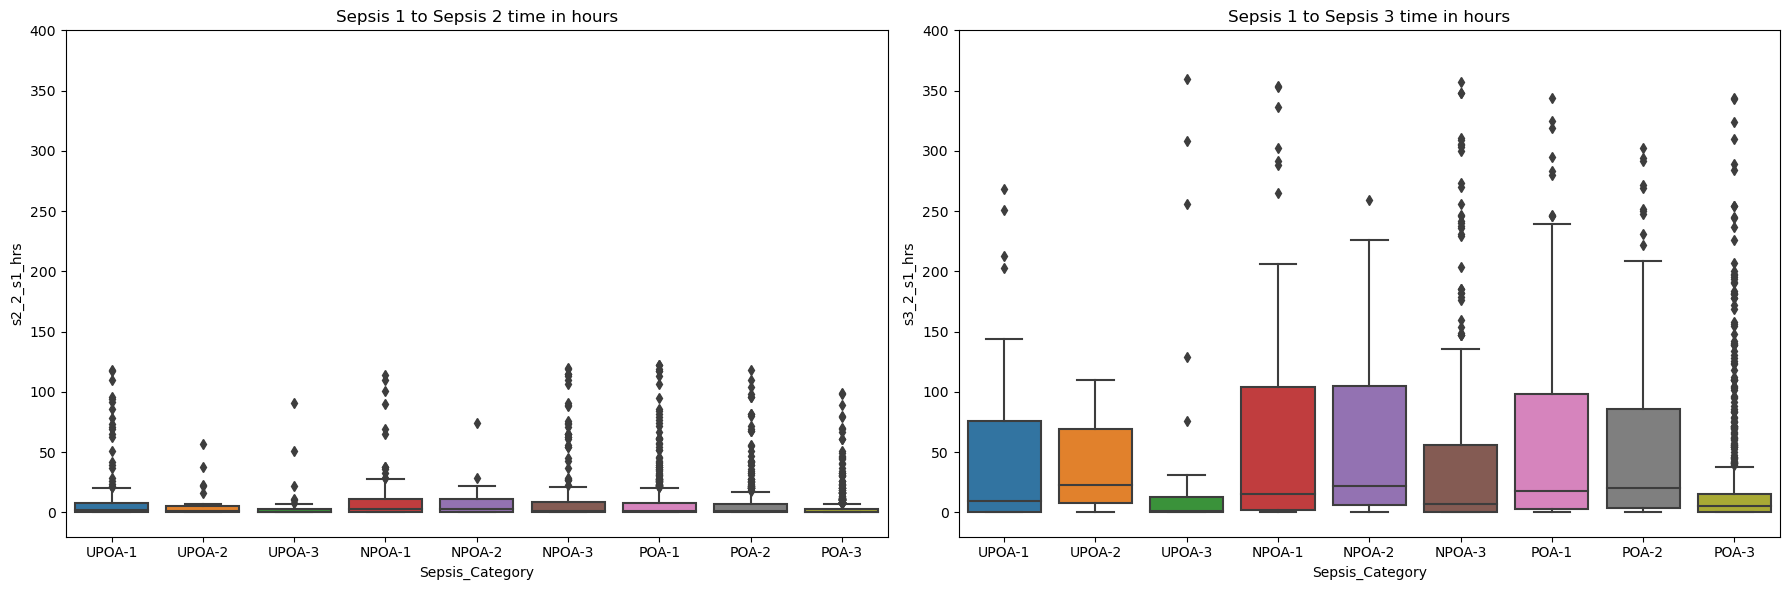

In [23]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

sns.boxplot(
    data=df.filter(
        (pl.col("s2_2_s1_hrs")>=pl.col("s2_2_s1_hrs").quantile(0.05))&
        (pl.col("s2_2_s1_hrs")<=pl.col("s2_2_s1_hrs").quantile(0.95))
        ).to_pandas(),
    x="Sepsis_Category",
    y="s2_2_s1_hrs",
    order=["UPOA-1","UPOA-2","UPOA-3","NPOA-1","NPOA-2","NPOA-3","POA-1","POA-2","POA-3"],
    ax=axes[0]
)

sns.boxplot(
    data=df.filter(
        (pl.col("s3_2_s1_hrs")>=pl.col("s3_2_s1_hrs").quantile(0.05))&
        (pl.col("s3_2_s1_hrs")<=pl.col("s3_2_s1_hrs").quantile(0.95))
        ).to_pandas(),
    x="Sepsis_Category",
    y="s3_2_s1_hrs",
    order=["UPOA-1","UPOA-2","UPOA-3","NPOA-1","NPOA-2","NPOA-3","POA-1","POA-2","POA-3"],
    ax=axes[1]
)

axes[0].set_title("Sepsis 1 to Sepsis 2 time in hours")
axes[0].set_ylim([-20, 400])

axes[1].set_title("Sepsis 1 to Sepsis 3 time in hours")
axes[1].set_ylim([-20, 400])

# axes[2].set_title("Sepsis 1 to Sepsis 3 time in hours")
# axes[2].set_ylim([-40, 500])

plt.tight_layout()

# Q7
What is the average/median time from Sepsis 2 to Sepsis 3?

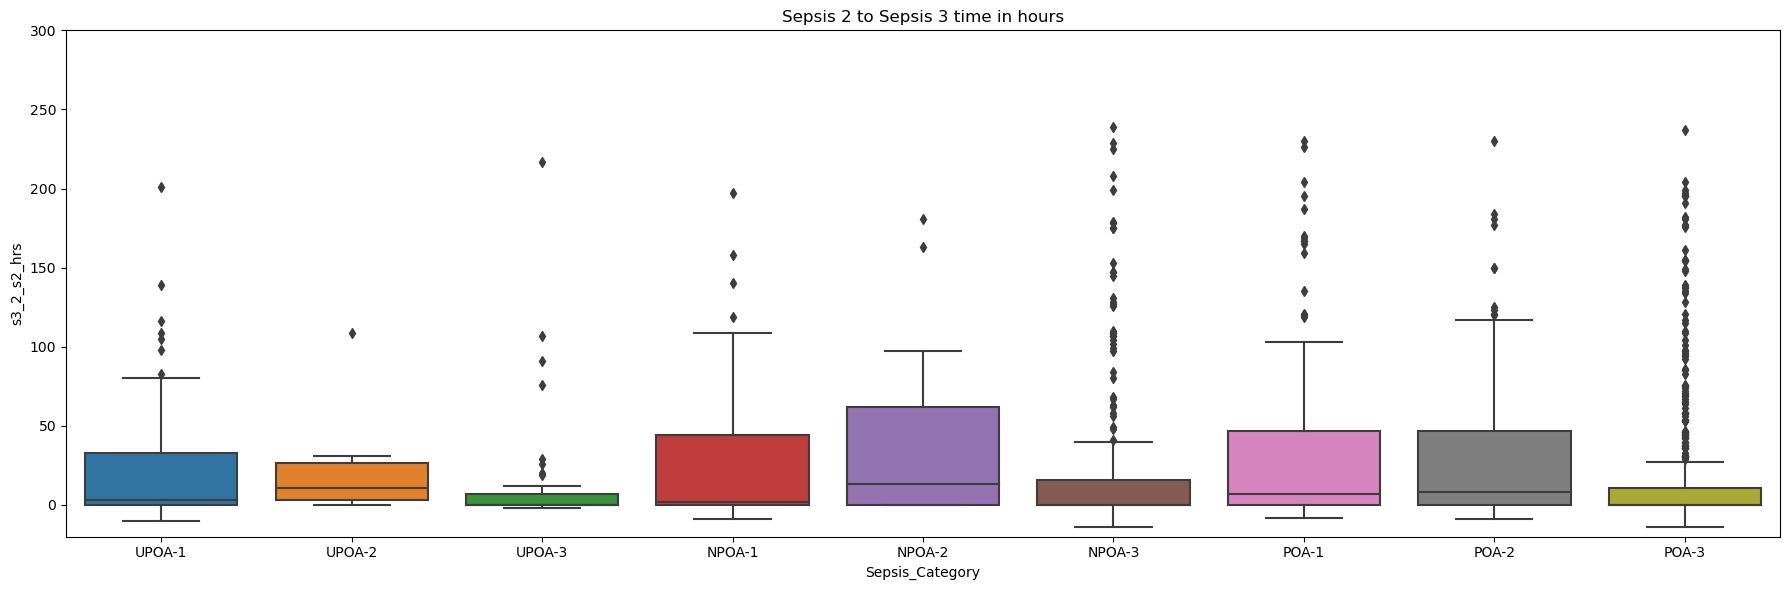

In [24]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))

sns.boxplot(
    data=df.filter(
        (pl.col("s3_2_s2_hrs")>=pl.col("s3_2_s2_hrs").quantile(0.05))&
        (pl.col("s3_2_s2_hrs")<=pl.col("s3_2_s2_hrs").quantile(0.95))
        ).to_pandas(),
    x="Sepsis_Category",
    y="s3_2_s2_hrs",
    order=["UPOA-1","UPOA-2","UPOA-3","NPOA-1","NPOA-2","NPOA-3","POA-1","POA-2","POA-3"],
    ax=axes
)
axes.set_title("Sepsis 2 to Sepsis 3 time in hours")
axes.set_ylim([-20, 300])

plt.tight_layout()

# Q8
How long do the encounters in each sepsis_category stay between each transision (admit, sepsis 1, sepsis 2, sepsis 3)?

In [45]:
df.columns[-12:]

['Max_Norepinephrine_Dose',
 'Max_Epinephrine_Dose',
 'admit_2_s1_hrs',
 'admit_2_s2_hrs',
 'admit_2_s3_hrs',
 'admit_2_infect_hrs',
 's2_2_s1_hrs',
 's3_2_s2_hrs',
 's3_2_s1_hrs',
 's1_2_infect_hrs',
 's2_2_infect_hrs',
 's3_2_infect_hrs']

In [70]:
df_long = pl.concat([
    df.select([
        "Sepsis_Category",
        pl.col("admit_2_infect_hrs").alias("hours"),
        pl.lit("Admit_2_Suspected").alias("interval")
    ]),
    df.select([
        "Sepsis_Category",
        pl.col("s1_2_infect_hrs").alias("hours"),
        pl.lit("S1_2_Infect").alias("interval")
    ]),
    df.select([
        "Sepsis_Category",
        pl.col("s2_2_s1_hrs").alias("hours"),
        pl.lit("S1_2_S2").alias("interval")
    ]),
    df.select([
        "Sepsis_Category",
        pl.col("s3_2_s2_hrs").alias("hours"),
        pl.lit("S2_2_S3").alias("interval")
    ]),
]).filter(pl.col("hours").is_not_null())

In [71]:
import plotly.express as px

pdf = df_long.to_pandas()

fig = px.violin(
    pdf,
    x="Sepsis_Category",
    y="hours",
    color="Sepsis_Category",
    facet_col="interval",
    box=True,            # show box inside violin
    points="outliers",   # or "all" if you want every point
    category_orders={"Sepsis_Category": ORDER_COLS}
)
fig.update_yaxes(title="Hours")
fig.update_xaxes(title="")
fig.update_layout(
    title="Time intervals by final sepsis category",
    violingap=0.15,
    violinmode="group",
)
# fig.update_yaxes(type="log")

fig.show()


In [76]:
def transition(df, src, tgt, col):
    return (
        df.filter(pl.col(col).is_not_null())
          .select([
              pl.lit(src).alias("source"),
              pl.lit(tgt).alias("target"),
              pl.len().alias("value"),
              pl.col(col).median().alias("median_hours")
          ])
    )

df_links = pl.concat([
    transition(df, "Admit", "Suspected", "admit_2_infect_hrs"),
    transition(df, "Suspected", "S1", "s1_2_infect_hrs"),
    transition(df, "S1", "S2", "s2_2_s1_hrs"),
    transition(df, "S2", "S3", "s3_2_s2_hrs"),
])


In [78]:
import plotly.graph_objects as go

nodes = ["Admit", "Suspected", "S1", "S2", "S3"]
node_idx = {n: i for i, n in enumerate(nodes)}

pdf_links = df_links.to_pandas()

fig = go.Figure(
    go.Sankey(
        node=dict(label=nodes, pad=20, thickness=18),
        link=dict(
            source=pdf_links["source"].map(node_idx),
            target=pdf_links["target"].map(node_idx),
            value=pdf_links["value"],
            customdata=pdf_links["median_hours"],
            hovertemplate=(
                "%{source.label} -> %{target.label}<br>"
                "n=%{value}<br>"
                "median=%{customdata:.1f}h<extra></extra>"
            ),
        ),
    )
)

fig.update_layout(title="Sepsis progression with suspected infection (counts + median hours)")
fig.show()


In [79]:
df.columns[-20:]

['Lactate_2',
 'Sepsis_3_Begin_DateTime',
 'Vasopressor',
 'Hypotensive',
 'Highest_SBP_in_15_NonNull',
 'Highest_MAP_in_15_NonNull',
 'Max_Vasopressin_Dose',
 'Max_Phenylephrine_Dose',
 'Max_Norepinephrine_Dose',
 'Max_Epinephrine_Dose',
 'admit_2_s1_hrs',
 'admit_2_s2_hrs',
 'admit_2_s3_hrs',
 'admit_2_infect_hrs',
 's2_2_s1_hrs',
 's3_2_s2_hrs',
 's3_2_s1_hrs',
 's1_2_infect_hrs',
 's2_2_infect_hrs',
 's3_2_infect_hrs']

In [80]:
datetime_cols

['InpatientAdmissionInstant',
 'Suspected_Infection_Datetime',
 'Sepsis_1_Begin_DateTime',
 'Sepsis_2_Begin_DateTime',
 'Sepsis_3_Begin_DateTime']

In [83]:
import polars as pl
import plotly.graph_objects as go

NODES = ["Admit", "Suspected", "No Suspected", "S1", "No S1", "S2", "No S2", "S3", "No S3"]
IDX = {n: i for i, n in enumerate(NODES)}

def _count(df_cat: pl.DataFrame, cond: pl.Expr) -> int:
    return df_cat.select(cond.sum()).item()

def sankey_for_category_with_dropoffs(df: pl.DataFrame, cat: str) -> go.Figure:
    d = df.filter(pl.col("Sepsis_Category") == cat)

    # presence flags based on intervals (or use datetimes if you prefer)
    has_sus = pl.col("Suspected_Infection_Datetime").is_not_null()
    has_s1  = pl.col("Sepsis_1_Begin_DateTime").is_not_null()
    has_s2  = pl.col("Sepsis_2_Begin_DateTime").is_not_null()
    has_s3  = pl.col("Sepsis_3_Begin_DateTime").is_not_null()

    # Counts for branching
    n_total = d.height

    n_sus = _count(d, has_sus)
    n_no_sus = n_total - n_sus

    n_s1 = _count(d, has_sus & has_s1)
    n_no_s1 = n_sus - n_s1

    n_s2 = _count(d, has_sus & has_s1 & has_s2)
    n_no_s2 = n_s1 - n_s2

    n_s3 = _count(d, has_sus & has_s1 & has_s2 & has_s3)
    n_no_s3 = n_s2 - n_s3

    # Optional medians for main-path links only
    med_admit_sus = d.filter(has_sus).select(pl.col("admit_2_infect_hrs").median()).item() if n_sus else None
    med_sus_s1    = d.filter(has_sus & has_s1).select(pl.col("s1_2_infect_hrs").median()).item() if n_s1 else None
    med_s1_s2     = d.filter(has_sus & has_s1 & has_s2).select(pl.col("s2_2_s1_hrs").median()).item() if n_s2 else None
    med_s2_s3     = d.filter(has_sus & has_s1 & has_s2 & has_s3).select(pl.col("s3_2_s2_hrs").median()).item() if n_s3 else None

    # Build links
    sources, targets, values, hovers = [], [], [], []

    def add_link(src, tgt, val, med=None):
        if val <= 0:
            return
        sources.append(IDX[src]); targets.append(IDX[tgt]); values.append(int(val))
        if med is None:
            hovers.append(f"{src}->{tgt}<br>n={int(val)}")
        else:
            hovers.append(f"{src}->{tgt}<br>n={int(val)}<br>median={med:.1f}h")

    add_link("Admit", "Suspected", n_sus, med_admit_sus)
    add_link("Admit", "No Suspected", n_no_sus)

    add_link("Suspected", "S1", n_s1, med_sus_s1)
    add_link("Suspected", "No S1", n_no_s1)

    add_link("S1", "S2", n_s2, med_s1_s2)
    add_link("S1", "No S2", n_no_s2)

    add_link("S2", "S3", n_s3, med_s2_s3)
    add_link("S2", "No S3", n_no_s3)

    fig = go.Figure(
        go.Sankey(
            node=dict(label=NODES, pad=18, thickness=18),
            link=dict(
                source=sources, target=targets, value=values,
                customdata=hovers,
                hovertemplate="%{customdata}<extra></extra>",
            ),
        )
    )
    fig.update_layout(title=f"Sankey: {cat} (with drop-offs)")
    return fig

# Example
# for cat in ["No Sepsis", "Sepsis 1", "Sepsis 2", "Sepsis 3"]:
#     sankey_for_category_with_dropoffs(df, cat).show()

- States: ADmit, S1, S2, S3.. independent on Suspected and SIRS
- Confusion matrix between billing diagnosis, our final classification

In [84]:
for cat in ORDER_COLS:
    sankey_for_category_with_dropoffs(df, cat).show()

# Q8
Analyze factors (columns) contributing to the values above. 